**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 17 -  📊 Introducción al análisis de inversiones con Python (II)**

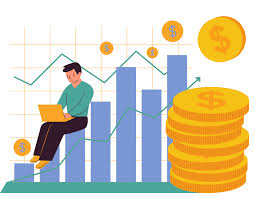

# 📐 Seguimos con las formulas:




6.   Tasa interna de retorno (TIR)
7.   Tasa interna de retorno modificada (TIRM)
8.   Indice de rentabilidad (IR)
9.   Periodo de recuperacion simple (PRS)
10.   Periodo de recuperacion descontado (PRD)

---











### ***6) Tasa Interna de Retorno (TIR)***

La Tasa Interna de Retorno (TIR) es la tasa de descuento que hace que el Valor Actual Neto (VAN) de todos los flujos de caja de un proyecto de inversión sea igual a cero. Representa la rentabilidad intrínseca del proyecto.

**La fórmula es implícita y generalmente requiere métodos iterativos para su cálculo:**

$$
\sum_{t=0}^{n} \frac{F_t}{(1+TIR)^t} = 0
$$

Donde:

-$ F_t $: Flujo de caja en el período \( t \)
- $ TIR $: Tasa Interna de Retorno
- $ t $: Período de tiempo
- $ n $: Número total de períodos

**Interpretación de la TIR:**

- Si **TIR > r** (Tasa de descuento o costo de capital): El proyecto es rentable y conviene aceptarlo.
- Si **TIR < r**: El proyecto no es rentable y no conviene aceptarlo.
- Si **TIR = r**: El proyecto es indiferente.

# Caso NVDA 🤖

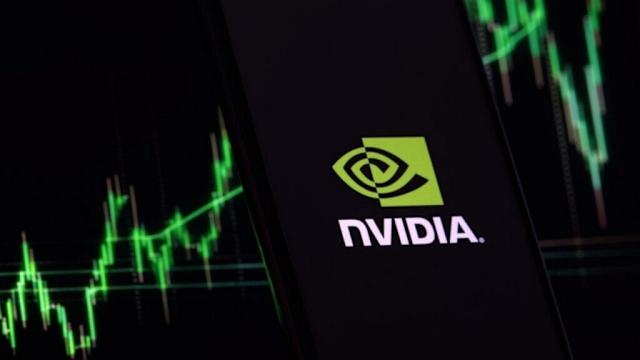

In [ ]:
import yfinance as yf #traemos info del mercado 15´ retrasados
import pandas as pd

#ticker de la empresa a analizar
ticker_symbol = "NVDA" #Podemos analizar cualquier empresa que cotize en el mercado

# Descargar la info del mercado
ticker_data = yf.Ticker(ticker_symbol)
df = ticker_data.history(period="5y") # Se puede ajustar el periodo de analisis.
display(df.head())

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-05-27 00:00:00-04:00,15.660279,15.710403,15.421132,15.449061,581476000,0.0,0.0
2021-05-28 00:00:00-04:00,15.462028,16.236575,15.462028,16.203657,644536000,0.0,0.0
2021-06-01 00:00:00-04:00,16.229097,16.347049,15.863268,16.223610,472804000,0.0,0.0
2021-06-02 00:00:00-04:00,16.211392,16.876217,16.194684,16.736069,594168000,0.0,0.0
2021-06-03 00:00:00-04:00,16.658765,17.215612,16.541311,16.927088,580008000,0.0,0.0


In [ ]:
#Nos quedamos con el cierre de la fecha
df_selected = df[['Close']]
display(df_selected.head())

,Close
Date,
2021-05-27 00:00:00-04:00,15.449061
2021-05-28 00:00:00-04:00,16.203657
2021-06-01 00:00:00-04:00,16.223610
2021-06-02 00:00:00-04:00,16.736069
2021-06-03 00:00:00-04:00,16.927088


In [ ]:
df_selected

,Close
Date,
2021-05-27 00:00:00-04:00,15.449061
2021-05-28 00:00:00-04:00,16.203657
2021-06-01 00:00:00-04:00,16.223610
2021-06-02 00:00:00-04:00,16.736069
2021-06-03 00:00:00-04:00,16.927088
...,...
2026-05-19 00:00:00-04:00,220.610001
2026-05-20 00:00:00-04:00,223.470001
2026-05-21 00:00:00-04:00,219.509995


In [ ]:
df_selected['Year'] = df_selected.index.year
df_PROMAÑO = df_selected.groupby('Year')['Close'].mean().reset_index()


df_PROMAÑO.columns = ['Año', 'Promedio de Cierre de Acción']
display(df_PROMAÑO)

/tmp/ipykernel_7547/1904090759.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Year'] = df_selected.index.year


,Año,Promedio de Cierre de Acción
0,2021,23.123688
1,2022,18.538111
2,2023,36.540525
3,2024,107.774186
4,2025,153.874946
5,2026,191.525939


In [ ]:
#  nueva columna 'cantidad de acciones compradas' todo valor 0
df_PROMAÑO['cantidad de acciones compradas'] = 0

# excepto el primer elemento
df_PROMAÑO.loc[0, 'cantidad de acciones compradas'] = 10
display(df_PROMAÑO)

,Año,Promedio de Cierre de Acción,cantidad de acciones compradas
0,2021,23.123688,10
1,2022,18.538111,0
2,2023,36.540525,0
3,2024,107.774186,0
4,2025,153.874946,0
5,2026,191.525939,0


In [ ]:

# Calcular la inversión inicial para el Año 0
initial_investment = -df_PROMAÑO.loc[0, 'Promedio de Cierre de Acción'] * df_PROMAÑO.loc[0, 'cantidad de acciones compradas']


# Agregar la columna 'Flujo' e inicializarla con ceros
df_PROMAÑO['Flujo'] = 0


# Establecer el flujo para el Año 0 como la inversión inicial
df_PROMAÑO.loc[0, 'Flujo'] = initial_investment
# Calcular el flujo de caja para los años subsiguientes

# Para los años intermedios, el flujo es el cambio en el valor de la inversión
df_PROMAÑO['Flujo'] = df_PROMAÑO['Promedio de Cierre de Acción'].diff() * df_PROMAÑO['cantidad de acciones compradas'].iloc[0]



# El flujo en el año 0 es la inversión inicial
df_PROMAÑO.loc[0, 'Flujo'] = initial_investment


# En el último año, el flujo es el valor de la inversión (venta de acciones)
df_PROMAÑO.loc[df_PROMAÑO.index[-1], 'Flujo'] = df_PROMAÑO.loc[df_PROMAÑO.index[-1], 'Promedio de Cierre de Acción'] * df_PROMAÑO['cantidad de acciones compradas'].iloc[0]
display(df_PROMAÑO)

/tmp/ipykernel_7547/1635302698.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-231.2368832763873' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_PROMAÑO.loc[0, 'Flujo'] = initial_investment


,Año,Promedio de Cierre de Acción,cantidad de acciones compradas,Flujo
0,2021,23.123688,10,-231.236883
1,2022,18.538111,0,-45.855775
2,2023,36.540525,0,180.024145
3,2024,107.774186,0,712.336610
4,2025,153.874946,0,461.007596
5,2026,191.525939,0,1915.259390


In [ ]:
!pip install numpy_financial

###  ¿Qué es `numpy-financial`?

`numpy-financial` es una librería de Python que reúne funciones financieras comunes, separada de NumPy para mantenerla enfocada en cálculos numéricos generales. Permite realizar:

*   **Cálculos de valor presente y futuro** (por ejemplo, `npf.pv()`, `npf.fv()`), útiles para valorar inversiones.
*   **Análisis de flujos de caja** (por ejemplo, `npf.irr()`, `npf.npv()`), esenciales para evaluar la rentabilidad de proyectos.
*   **Cálculos de anualidades**, aplicables a préstamos, hipotecas o planes de ahorro.
*   **Operaciones básicas con bonos y valores**.

En síntesis, es una herramienta práctica para realizar cálculos financieros de forma eficiente, especialmente al trabajar con grandes conjuntos de datos numéricos. 📊

In [ ]:
#Dataframe ready para utilizar con nuestras herramientas ;)
display(df_PROMAÑO)

,Año,Promedio de Cierre de Acción,cantidad de acciones compradas,Flujo
0,2021,23.074909,10,-230.749090
1,2022,18.538111,0,-45.367981
2,2023,36.540525,0,180.024143
3,2024,107.774186,0,712.336609
4,2025,153.874946,0,461.007599
5,2026,191.509323,0,1915.093228


In [ ]:
import numpy_financial as nf

# Calculamos tir
tir = nf.irr(df_PROMAÑO['Flujo'])
print(f"La Tasa Interna de Retorno (TIR) es: {tir:.2%}")

La Tasa Interna de Retorno (TIR) es: 92.37%


In [ ]:
# Calcular el cambio porcentual anual en el precio de cierre promedio
df_PROMAÑO['Annual_Price_Change'] = df_PROMAÑO['Promedio de Cierre de Acción'].pct_change()
display(df_PROMAÑO)

# También puedes calcular el cambio de precio anual promedio (excluyendo el primer valor NaN)
average_annual_price_change = df_PROMAÑO['Annual_Price_Change'].dropna().mean()
print(f"promedio de cambio de precios: {average_annual_price_change:}")

,Año,Promedio de Cierre de Acción,cantidad de acciones compradas,Flujo,Annual_Price_Change
0,2021,23.074909,10,-230.749090,NaN
1,2022,18.538111,0,-45.367981,-0.196612
2,2023,36.540525,0,180.024143,0.971103
3,2024,107.774186,0,712.336609,1.949443
4,2025,153.874946,0,461.007599,0.427753
5,2026,191.509323,0,1915.093228,0.244578


promedio de cambio de precios: 0.6792529745029091


Como podemos observar en este caso, TIR > r (En este caso considereandolo como el promedio de cambio de precios año a año). Podemos considerar que la inversion es rentable.

---

### ***7) Tasa Interna de Retorno Modificada (TIRM)***

La Tasa Interna de Retorno Modificada (TIRM) aborda una de las críticas de la TIR tradicional: la suposición de que los flujos de caja intermedios se reinvierten a la propia TIR. La TIRM asume que los flujos de caja positivos se reinvierten a una tasa de reinversión específica (generalmente el costo de capital), y los flujos de caja negativos se descuentan al costo de financiamiento.

**Fórmula de la TIRM:**

$$
TIRM = \left( \frac{VF_{positivos}}{VP_{negativos}} \right)^{\frac{1}{n}} - 1
$$

Donde:

- $ VF_{positivos} $: Valor futuro de los flujos de caja positivos (reinvertidos a la tasa de reinversión).
- $ VP_{negativos} $: Valor presente de los flujos de caja negativos (descontados al costo de financiamiento).
- $ n $: Número total de períodos.

**Interpretación de la TIRM:**

- Si **TIRM > r** (Tasa de reinversión/costo de capital): El proyecto es rentable y conviene aceptarlo.
- Si **TIRM < r**: El proyecto no es rentable y no conviene aceptarlo.
- Si **TIRM = r**: El proyecto es indiferente.

In [ ]:
import numpy_financial as npf
tirm_result = npf.mirr(df_PROMAÑO['Flujo'].tolist(), 0.73, 0.73) # (FLUJO, TASA DE FINANCIAMIENTO,  TASA DE REINVERSION)

print("La Tasa interna de Retorno Modificada es :", tirm_result*100)

La Tasa interna de Retorno Modificada es : 86.36243820285921


TIRM > R. Es rentable

---

### ***8) Índice de Rentabilidad (IR)***

El Índice de Rentabilidad (IR), también conocido como relación beneficio/costo, mide el valor presente de los flujos de caja futuros generados por un proyecto por cada unidad monetaria invertida. Se calcula dividiendo el valor presente de los flujos de caja futuros (excluyendo la inversión inicial) entre el valor presente de la inversión inicial.

**Fórmula del IR:**

$$
IR = \frac{VAN}{\text{Inversión inicial}}
$$


Donde:

- $ VAN $: Valor actual neto
- $ I_0 $: Inversión inicial (tomada en valor absoluto y traída a valor presente si ocurre en un período > 0)

**Interpretación del IR:**

- Si **IR > 1**: El valor presente de los beneficios es mayor que la inversión inicial, el proyecto es rentable. Conviene aceptar el proyecto.
- If **IR < 1**: El valor presente de los beneficios es menor que la inversión inicial, el proyecto no es rentable. No conviene aceptar el proyecto.
- If **IR = 1**: El valor presente de los beneficios es igual a la inversión inicial, el proyecto es indiferente.

In [ ]:
import numpy_financial as nf

# Tasa de descuento de capital R
r_desc_ir = 0.73

# Flujo
flujos_ir = df_PROMAÑO['Flujo'].tolist()

# Separo Inversion inicial y flujos futuros
I_inicial = abs(flujos_ir[0])

# VAN
van = nf.npv(r_desc_ir, flujos_ir)
# Indice de rentabilidad
ir = van / I_inicial
print(f"El Índice de Rentabilidad (IR) es: {ir:.2f}")

El Índice de Rentabilidad (IR) es: 0.50


IR < 1 no rentable

---

### ***9) Periodo de Recuperación Simple (PRS)***

El Periodo de Recuperación Simple (PRS) es el tiempo que tarda un proyecto de inversión en recuperar la inversión inicial con los flujos de caja brutos (sin descontar). Es una medida de liquidez, no de rentabilidad.

**Cálculo del PRS:**

Se calcula sumando los flujos de caja anuales hasta que la suma sea igual o mayor que la inversión inicial. Si la recuperación ocurre dentro de un año, se puede interpolar linealmente.

**Interpretación del PRS:**

Generalmente, se compara con un período de recuperación máximo aceptable definido por la empresa. Proyectos con PRS más cortos suelen ser preferibles, ya que recuperan la inversión más rápido, aunque no considera la rentabilidad después del período de recuperación ni el valor del dinero en el tiempo.

In [ ]:
#flujos como una lista
flujos_prs = df_PROMAÑO['Flujo'].tolist()

#inversión inicial
I_inicial = abs(flujos_prs[0])

# Inicializar variables para el flujo de caja acumulado y el período de recuperación
cumulative_cash_flow = 0 #el flujo de caja acumulativo comienza en 0
prs = None

# luego , Iterar a través de los flujos de caja comenzando desde el primer período (después de la inversión inicial)
for t in range(1, len(flujos_prs)):
    cumulative_cash_flow += flujos_prs[t]

    # Verificar si el flujo de caja acumulado es mayor o igual a la inversión inicial
    if cumulative_cash_flow >= I_inicial:
        # Si es así, calcular el período de recuperación
        # El período de recuperación es el período actual 't' más la fracción del flujo del último período necesaria para cubrir la inversión restante
        remaining_investment = I_inicial - (cumulative_cash_flow - flujos_prs[t])
        prs = t - 1 + (remaining_investment / flujos_prs[t])
        break

# Mostrar el Periodo de Recuperación Simple (PRS) calculado
if prs is not None:
    print(f"El Periodo de Recuperación Simple (PRS) es: {prs:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis.")

El Periodo de Recuperación Simple (PRS) es: 2.14 años


Si yo compro las acciones luego de 2 años y medio practicamente, estaria recuperando mi inversion Inicial.

---

### ***10) Periodo de Recuperación Descontado (PRD)***

El Periodo de Recuperación Descontado (PRD) es similar al PRS, pero utiliza los flujos de caja descontados para calcular el tiempo que tarda en recuperarse la inversión inicial. Esta métrica sí considera el valor del dinero en el tiempo.

**Cálculo del PRD:**

Se calcula sumando los flujos de caja descontados anualmente hasta que la suma sea igual o mayor que la inversión inicial.

**Interpretación del PRD:**

Al igual que el PRS, se compara con un período de recuperación máximo aceptable. El PRD siempre será mayor que el PRS (o igual si la tasa de descuento es cero). Proyectos con PRD más cortos son generalmente preferibles, pero sigue sin considerar la rentabilidad después del período de recuperación.

In [ ]:
# Definir la tasa de descuento (usando la misma tasa que para VAN/IR)
r_desc_prd = r_desc_ir

# Obtener los flujos de caja como una lista
flujos_prd = df_PROMAÑO['Flujo'].tolist()

# Obtener la inversión inicial (valor absoluto del primer flujo de caja)
I_inicial = abs(flujos_prd[0])

# Misma historia
cumulative_discounted_cash_flow = 0
prd = None

# Misma historia
for t in range(1, len(flujos_prd)):
    # Descontar el flujo de caja actual
    discounted_flow = flujos_prd[t] / (1 + r_desc_prd)**t # aaaaa pero aca cambia se descuentan los flujos periodo periodo por la tasa de costo de capital.
    cumulative_discounted_cash_flow += discounted_flow

    # Verificar si el flujo de caja descontado acumulado es mayor o igual a la inversión inicial
    if cumulative_discounted_cash_flow >= I_inicial:
        # Si es así, calcular el período de recuperación descontado
        # El período de recuperación descontado es el período actual 't' más la fracción del flujo descontado del último período necesaria para cubrir la inversión restante
        remaining_investment = I_inicial - (cumulative_discounted_cash_flow - discounted_flow)
        prd = t - 1 + (remaining_investment / discounted_flow)
        break

if prd is not None:
    print(f"El Periodo de Recuperación Descontado (PRD) es: {prd:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis descontado.")

El Periodo de Recuperación Descontado (PRD) es: 4.07 años


---

In [ ]:
!pip install numpy_financial

numpy financial es un atajo por que no lo usamos??

| Tipo de cálculo               | ¿Disponible en `numpy-financial`? |
| ----------------------------- | :-------------------------------: |
| Equivalencia                  |                 ❌                 |
| Proporción                    |                 ❌                 |
| Valor Presente (PV)           |                 ✅                 |
| Valor Futuro (FV)             |                 ✅                 |
| Valor Actual Neto (VAN / NPV) |                 ✅                 |
| TIR                           |                 ✅                 |
| TIRM                          |                 ✅                 |
| Índice de Rentabilidad (IR)   |        ❌        |
| PRS                           |             ❌            |
| PRD                           |     ❌      |


Pueden utilizar atajos en vez de hacer toooda las ecuaciones, los ejemplos son de la clase de hoy. pero la clase pasada hay muchas de las ecuaciones que son sencillas de hacer en con numpy financial y nos ahorran tiempo.

* VAN

In [ ]:
import numpy_financial as nf

# Definir la tasa de descuento (usando la misma tasa que para el PRD)
tasa_descuento_van = r_desc_prd

# Obtener los flujos de caja como una lista
flujos_van = df_PROMAÑO['Flujo'].tolist()

# npf.npv(tasa, valores) calcula el valor presente neto de una serie de flujos de caja periódicos.
# El primer valor en la lista 'valores' es el flujo de caja en el momento 0.
resultado_van = nf.npv(tasa_descuento_van, flujos_van)
print(f"El Valor Presente Neto (VAN/NPV) de los flujos de NVDA es: {resultado_van:.2f}")

El Valor Presente Neto (VAN/NPV) de los flujos de NVDA es: 115.80


* Valor presente

In [ ]:
flujo = 1000
periodos = 5
tasa = 0.1

vp = nf.pv(rate=tasa, nper=periodos, pmt=flujo, fv=0, when='end') #fv=0 porque no hay valor futuro establecido , los pagos se reciben al final dado que son acciones, end.
print(f"Valor Presente (VP) de la anualidad: {abs(vp):.2f}")

Valor Presente (VP) de la anualidad: 3790.79


* Valor futuro

In [ ]:
flujo = 1000
periodos = 5
tasa = 0.1

vf = nf.fv(rate=tasa, nper=periodos, pmt=flujo, pv=0, when='end') #pv=0 porque no hay valor presente establecido , los pagos se reciben al final dado que son acciones, end.
print(f"Valor Futuro (VF) de la anualidad: {abs(vf):.2f}")

Valor Futuro (VF) de la anualidad: 6105.10


## Resumen breve de Valor Presente (VP) y Valor Futuro (VF)

Estas son operaciones de equivalencia temporal aplicadas a flujos de dinero concretos, no a tasas. Sirven para llevar flujos de efectivo en el tiempo a un punto común (presente o futuro).

**Ejemplo:**

💡 Querés saber cuánto valen hoy (VP) o cuánto valdrán en 5 años (VF) pagos de 1000 $ anuales al 10%.

### Cálculo del Valor Presente (VP):

La fórmula general para el Valor Presente de una serie de flujos desiguales es:

$$
VP = \sum_{t=1}^{n} \frac{F_t}{(1+r)^t}
$$

Para una anualidad (pagos iguales), se puede usar la fórmula simplificada o `numpy_financial.pv()`:

$$
VP_{anualidad} = PMT \times \frac{1 - (1+r)^{-n}}{r}
$$

### Cálculo del Valor Futuro (VF):

La fórmula general para el Valor Futuro de una serie de flujos desiguales es más compleja y depende del momento en que ocurren los flujos. Para una anualidad (pagos iguales), se puede usar la fórmula simplificada o `numpy_financial.fv()`:

$$
VF_{anualidad} = PMT \times \frac{(1+r)^n - 1}{r}
$$

* Estas fórmulas te “trasladan dinero en el tiempo”. No cambian la tasa, sino que usan la tasa dada para traer o llevar montos.

## Resumen Breve de Equivalencia y Proporción de Tasas

Estas son operaciones entre tasas de interés, no entre flujos. Sirven para convertir tasas que están expresadas en distintos períodos o bases (por ejemplo, de mensual a anual, o de nominal a efectiva).

** Ejemplo:**

💡Si tenés una tasa mensual del 2 %, su equivalente anual efectiva es:

$$
Tasa Anual Efectiva = (1 + Tasa\ Mensual)^{12} - 1 = (1+0.02)^{12} - 1 \approx 0.2682 = 26.82\%
$$

O, al revés, si tenés una tasa efectiva anual del 26.82 %, la mensual equivalente es:

$$
Tasa Mensual Equivalente = (1 + Tasa\ Anual\ Efectiva)^{1/12} - 1 = (1+0.2682)^{1/12} - 1 \approx 0.02 = 2\%
$$

* Es decir, la equivalencia de tasas transforma una tasa en otra que produce el mismo efecto financiero, pero en distinto período. La proporción de tasas (que no se mostró en el ejemplo pero es relevante) simplemente escala una tasa nominal a diferentes períodos sin considerar la capitalización (por ejemplo, una tasa nominal anual del 12% pagadera mensualmente sería 1% mensual simple, 12%/12).

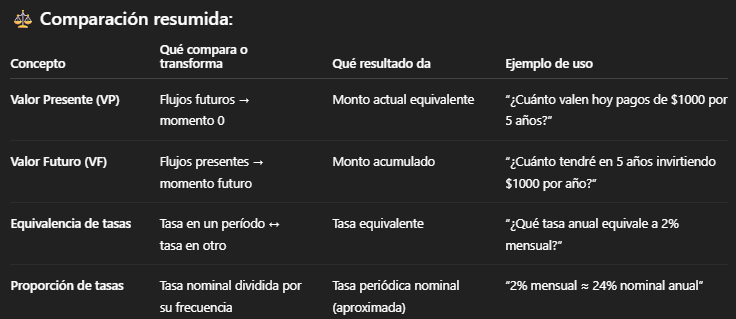

---

In [ ]:
#@title Easter egg 🥚
from IPython.display import Image
Image(url='https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExcmVndm5ma3hyajA5NncwbTQ5azRsbXY5dHlvamQ2bXJuZDRwdnF4aiZlcD12MV9naWZzX3NlYXJjaCZjdD1n/Rlwz4m0aHgXH13jyrE/giphy.gif')

#Ejercicios


Ejercicio 1

---



In [ ]:
# Ejercicio 1: Análisis de un proyecto de inversión
# Definir los flujos de caja del proyecto (incluyendo la inversión inicial)
# Ejemplo: Inversión inicial de -10000, flujos de caja de 3000, 4000, 5000, 3000 en los años 1 a 4.
flujos_ejercicio = [-10000, 3000, 4000, 5000, 3000]

# Definir la tasa de descuento (costo de capital) para el proyecto
tasa_descuento_ejercicio = 0.10 # 10%

print("Flujos de Caja del Ejercicio:", flujos_ejercicio)
print("Tasa de Descuento:", tasa_descuento_ejercicio)

Flujos de Caja del Ejercicio: [-10000, 3000, 4000, 5000, 3000]
Tasa de Descuento: 0.1


In [ ]:
import numpy_financial as nf

# Calcular el Valor Actual Neto (VAN)
van_ejercicio = nf.npv(tasa_descuento_ejercicio, flujos_ejercicio)
print(f"\nEl Valor Actual Neto (VAN) es: {van_ejercicio:.2f}")

# Calcular la Tasa Interna de Retorno (TIR)
tir_ejercicio = nf.irr(flujos_ejercicio)
print(f"La Tasa Interna de Retorno (TIR) es: {tir_ejercicio:.2%}")

# Calcular la Tasa Interna de Retorno Modificada (TIRM)
# Para la TIRM, necesitamos una tasa de financiamiento y una tasa de reinversión.
# Usaremos la tasa de descuento del ejercicio para ambas, como ejemplo.
tasa_financiamiento = tasa_descuento_ejercicio
tasa_reinversion = tasa_descuento_ejercicio
tirm_ejercicio = nf.mirr(flujos_ejercicio, tasa_financiamiento, tasa_reinversion)
print(f"La Tasa Interna de Retorno Modificada (TIRM) es: {tirm_ejercicio:.2%}")

# Calcular el Índice de Rentabilidad (IR)
# El IR se calcula como VAN / Inversión Inicial (en valor absoluto)
inversion_inicial_ejercicio = abs(flujos_ejercicio[0])
# Calculamos el VAN solo de los flujos futuros para el numerador del IR
van_flujos_futuros = nf.npv(tasa_descuento_ejercicio, flujos_ejercicio[1:])
ir_ejercicio = van_flujos_futuros / inversion_inicial_ejercicio
print(f"El Índice de Rentabilidad (IR) es: {ir_ejercicio:.2f}")

# Calcular el Periodo de Recuperación Simple (PRS)
cumulative_cash_flow_ejercicio = 0
prs_ejercicio = None
for t in range(len(flujos_ejercicio)):
    cumulative_cash_flow_ejercicio += flujos_ejercicio[t]
    if cumulative_cash_flow_ejercicio >= 0 and prs_ejercicio is None:
        # Encontrar el punto de recuperación
        previous_cumulative_flow = cumulative_cash_flow_ejercicio - flujos_ejercicio[t]
        remaining_needed = abs(previous_cumulative_flow)
        prs_ejercicio = t - 1 + (remaining_needed / flujos_ejercicio[t])
        break
if prs_ejercicio is not None:
    print(f"El Periodo de Recuperación Simple (PRS) es: {prs_ejercicio:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis simple.")

# Calcular el Periodo de Recuperación Descontado (PRD)
cumulative_discounted_cash_flow_ejercicio = 0
prd_ejercicio = None
# Descontar cada flujo y acumular
for t in range(len(flujos_ejercicio)):
    discounted_flow = flujos_ejercicio[t] / (1 + tasa_descuento_ejercicio)**t
    cumulative_discounted_cash_flow_ejercicio += discounted_flow

    if cumulative_discounted_cash_flow_ejercicio >= 0 and prd_ejercicio is None:
        # Encontrar el punto de recuperación descontado
        previous_cumulative_discounted_flow = cumulative_discounted_cash_flow_ejercicio - discounted_flow
        remaining_needed_discounted = abs(previous_cumulative_discounted_flow)
        prd_ejercicio = t - 1 + (remaining_needed_discounted / discounted_flow)
        break

if prd_ejercicio is not None:
    print(f"El Periodo de Recuperación Descontado (PRD) es: {prd_ejercicio:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis descontado.")


El Valor Actual Neto (VAN) es: 1838.67
La Tasa Interna de Retorno (TIR) es: 18.03%
La Tasa Interna de Retorno Modificada (TIRM) es: 14.74%
El Índice de Rentabilidad (IR) es: 1.30
El Periodo de Recuperación Simple (PRS) es: 2.60 años
El Periodo de Recuperación Descontado (PRD) es: 3.10 años


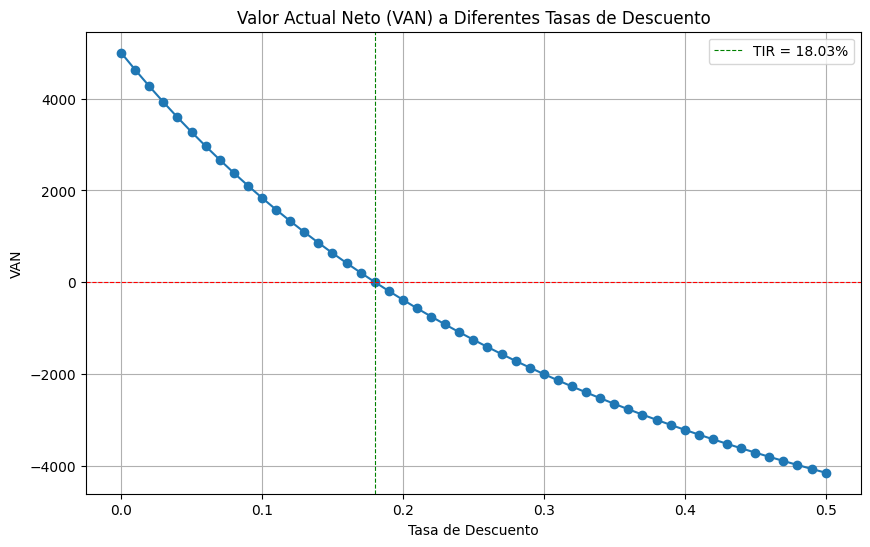

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy_financial as nf

# Definir los flujos de caja del proyecto (usaremos los del ejercicio anterior)
flujos_van_viz = flujos_ejercicio

# Crear un rango de tasas de descuento para evaluar el VAN
# Por ejemplo, de 0% a 50% con incrementos de 1%
tasas_descuento_rango = np.arange(0, 0.51, 0.01)

# Calcular el VAN para cada tasa de descuento en el rango
van_por_tasa = [nf.npv(tasa, flujos_van_viz) for tasa in tasas_descuento_rango]

# Visualizar el VAN a distintas tasas de descuento
plt.figure(figsize=(10, 6))
plt.plot(tasas_descuento_rango, van_por_tasa, marker='o', linestyle='-')
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Línea en VAN = 0 para identificar la TIR
plt.axvline(tir_ejercicio, color='green', linestyle='--', linewidth=0.8, label=f'TIR = {tir_ejercicio:.2%}') # Mostrar la TIR
plt.legend()
plt.show()

Ejercicio 2

---





In [ ]:
# Definimos los flujos de caja del nuevo proyecto de inversión (incluyendo la inversión inicial)
nuevos_flujos_ejercicio = [-20000, 5000, 4000, 3000, 3000, 2000, 2000, 1500, 1500, 1000, 1000]

# Vemos los nuevos flujos de caja
print("Nuevos Flujos de Caja del Ejercicio:", nuevos_flujos_ejercicio)

Nuevos Flujos de Caja del Ejercicio: [-20000, 5000, 4000, 3000, 3000, 2000, 2000, 1500, 1500, 1000, 1000]


In [ ]:
# Definimos la tasa de descuento (costo de capital) para el nuevo proyecto
nueva_tasa_descuento_ejercicio = 0.12  # 12%

# Imprimir la tasa de descuento
print("Nueva Tasa de Descuento:", nueva_tasa_descuento_ejercicio)

Nueva Tasa de Descuento: 0.12


In [ ]:
# Calculamos métricas financieras
# Calculamos el VAN
van_nuevos = nf.npv(nueva_tasa_descuento_ejercicio, nuevos_flujos_ejercicio)
print(f"\nEl Valor Actual Neto (VAN) es: {van_nuevos:.2f}")

# Calculamos la TIR
tir_nuevos = nf.irr(nuevos_flujos_ejercicio)
print(f"La Tasa Interna de Retorno (TIR) es: {tir_nuevos:.2%}")

# Calculamos la TIRM

tasa_financiamiento_nuevos = nueva_tasa_descuento_ejercicio
tasa_reinversion_nuevos = nueva_tasa_descuento_ejercicio
tirm_nuevos = nf.mirr(nuevos_flujos_ejercicio, tasa_financiamiento_nuevos, tasa_reinversion_nuevos)
print(f"La Tasa Interna de Retorno Modificada (TIRM) es: {tirm_nuevos:.2%}")

# Calculamos el IR

inversion_inicial_nuevos = abs(nuevos_flujos_ejercicio[0])
# Calculamos el VAN para el numerador
van_flujos_futuros_nuevos = nf.npv(nueva_tasa_descuento_ejercicio, nuevos_flujos_ejercicio[1:])

sum_pv_future_flows = sum([flow / (1 + nueva_tasa_descuento_ejercicio)**t for t, flow in enumerate(nuevos_flujos_ejercicio[1:], start=1)])
ir_nuevos = sum_pv_future_flows / inversion_inicial_nuevos
print(f"El Índice de Rentabilidad (IR) es: {ir_nuevos:.2f}")

# Calculamos el PRS
cumulative_cash_flow_nuevos = 0
prs_nuevos = None
for t in range(len(nuevos_flujos_ejercicio)):
    cumulative_cash_flow_nuevos += nuevos_flujos_ejercicio[t]
    if cumulative_cash_flow_nuevos >= 0 and prs_nuevos is None:

        previous_cumulative_flow_nuevos = cumulative_cash_flow_nuevos - nuevos_flujos_ejercicio[t]
        remaining_needed_nuevos = abs(previous_cumulative_flow_nuevos)

        if nuevos_flujos_ejercicio[t] > 0:
             prs_nuevos = t -1 + (remaining_needed_nuevos / nuevos_flujos_ejercicio[t])
        else:

             continue
        break

if prs_nuevos is not None:

    print(f"El Periodo de Recuperación Simple (PRS) es: {prs_nuevos:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis simple.")

# Calculamos el PRD
cumulative_discounted_cash_flow_nuevos = 0
prd_nuevos = None

for t in range(len(nuevos_flujos_ejercicio)):

    if t == 0:
        discounted_flow_nuevos = nuevos_flujos_ejercicio[t]
    else:
        discounted_flow_nuevos = nuevos_flujos_ejercicio[t] / (1 + nueva_tasa_descuento_ejercicio)**t

    cumulative_discounted_cash_flow_nuevos += discounted_flow_nuevos


    if cumulative_discounted_cash_flow_nuevos >= 0 and prd_nuevos is None:

        previous_cumulative_discounted_flow_nuevos = cumulative_discounted_cash_flow_nuevos - discounted_flow_nuevos
        remaining_needed_discounted_nuevos = abs(previous_cumulative_discounted_flow_nuevos)

        if discounted_flow_nuevos > 0:

             prd_nuevos = t - 1 + (remaining_needed_discounted_nuevos / discounted_flow_nuevos)
        else:

            continue
        break

if prd_nuevos is not None:
     print(f"El Periodo de Recuperación Descontado (PRD) es: {prd_nuevos:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis descontado.")


El Valor Actual Neto (VAN) es: -4190.00
La Tasa Interna de Retorno (TIR) es: 4.79%
La Tasa Interna de Retorno Modificada (TIRM) es: 9.40%
El Índice de Rentabilidad (IR) es: 0.79
El Periodo de Recuperación Simple (PRS) es: 6.67 años
La inversión inicial no se recupera dentro del período del análisis descontado.


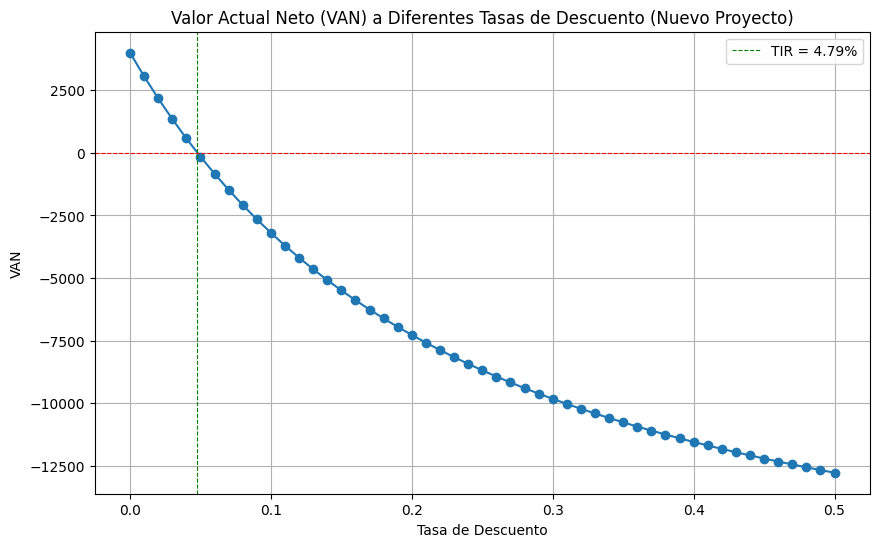

In [ ]:
# Creamos un rango de tasas para evaluar el VAN

tasas_descuento_rango_nuevos = np.arange(0, 0.51, 0.01)

# Calculamos el VAN para cada tasa de descuento
van_por_tasa_nuevos = [nf.npv(tasa, nuevos_flujos_ejercicio) for tasa in tasas_descuento_rango_nuevos]

# Visualizamos el VAN a distintas tasas de descuento
plt.figure(figsize=(10, 6))
plt.plot(tasas_descuento_rango_nuevos, van_por_tasa_nuevos, marker='o', linestyle='-')
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento (Nuevo Proyecto)')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Línea en VAN = 0 para identificar la TIR

if 0 <= tir_nuevos <= 0.50:
    plt.axvline(tir_nuevos, color='green', linestyle='--', linewidth=0.8, label=f'TIR = {tir_nuevos:.2%}') # Mostrar la TIR
plt.legend()
plt.show()

--- Análisis del Nuevo Proyecto de Inversión ---

Valor Actual Neto (VAN): -4190.00

Tasa Interna de Retorno (TIR): 4.79%

Tasa Interna de Retorno Modificada (TIRM): 9.40%

Índice de Rentabilidad (IR): 0.79

Periodo de Recuperación Simple (PRS): 6.67 años

Periodo de Recuperación Descontado (PRD): La inversión inicial no se recupera descontada.

Tasa de Descuento (Costo de Capital): 12.00%

---



Comparación con la Tasa de Descuento:
- La TIR (4.79%) es MENOR que la tasa de descuento (12.00%). Según el criterio de la TIR, el proyecto NO parece rentable.
- La TIRM (9.40%) es MENOR que la tasa de descuento (12.00%). Según el criterio de la TIRM, el proyecto NO parece rentable.

Interpretación del Índice de Rentabilidad (IR):
- El IR (0.79) es MENOR que 1. Esto indica que por cada unidad monetaria invertida, se espera recibir 0.79 unidades monetarias en valor presente de flujos futuros. El proyecto NO parece rentable según el IR.

Análisis de los Periodos de Recuperación:
- El Periodo de Recuperación Simple (PRS) es de 6.67 años. Este es el tiempo estimado para recuperar la inversión inicial sin descontar los flujos.
- El Periodo de Recuperación Descontado (PRD): La inversión inicial no se recupera dentro del período de análisis descontado. Esto es consistente con un VAN negativo, ya que el VAN negativo implica que los flujos descontados totales son menores que la inversión inicial, por lo tanto, la inversión inicial no se recupera en valor presente.

---



Observación del Gráfico del VAN:
- El gráfico muestra la relación entre la tasa de descuento y el VAN.
- La Tasa Interna de Retorno (TIR) calculada (4.79%) es el punto donde la curva del VAN cruza el eje horizontal (VAN = 0).
- Dado que el VAN es negativo para la tasa de descuento del 12%, la curva del VAN está por debajo del eje horizontal en este punto.

--- Resumen General de la Evaluación del Proyecto ---

Según la mayoría de las métricas (VAN, TIR, TIRM, IR), el proyecto NO parece ser RENTABLE a una tasa de descuento del 12%.
La inversión simple se recuperaría en aproximadamente 6.67 años, pero la inversión descontada NO se recupera dentro del período de análisis.

---



Ejercicio 3 - Comparamos 2 proyectos

---



In [ ]:
# Definimos los flujos de caja para el Proyecto A
flujos_proyecto_a = [-15000, 6000, 5000, 4000, 3000, 2000]

# Definimos los flujos de caja para el Proyecto B
flujos_proyecto_b = [-20000, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000]

# Imprimimos los flujos de caja para verificar
print("Flujos de Caja del Proyecto A:", flujos_proyecto_a)
print("Flujos de Caja del Proyecto B:", flujos_proyecto_b)

Flujos de Caja del Proyecto A: [-15000, 6000, 5000, 4000, 3000, 2000]
Flujos de Caja del Proyecto B: [-20000, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000]


In [ ]:
# Definimos la tasa de descuento común para ambos proyectos
tasa_descuento_comun = 0.15  # 15%

# Imprimimos la tasa de descuento para verificación
print(f"Tasa de Descuento Común para ambos proyectos: {tasa_descuento_comun:.2%}")

Tasa de Descuento Común para ambos proyectos: 15.00%


In [ ]:
#Métricas

# Calculamos métricas para el  Projecto A
van_proyecto_a = nf.npv(tasa_descuento_comun, flujos_proyecto_a)
tir_proyecto_a = nf.irr(flujos_proyecto_a)
tirm_proyecto_a = nf.mirr(flujos_proyecto_a, tasa_descuento_comun, tasa_descuento_comun)

# Calculamos IR
inversion_inicial_a = abs(flujos_proyecto_a[0])
sum_pv_future_flows_a = sum([flow / (1 + tasa_descuento_comun)**t for t, flow in enumerate(flujos_proyecto_a[1:], start=1)])
ir_proyecto_a = sum_pv_future_flows_a / inversion_inicial_a

# Calculamos PRS
cumulative_cash_flow_a = 0
prs_proyecto_a = None
for t in range(len(flujos_proyecto_a)):
    cumulative_cash_flow_a += flujos_proyecto_a[t]
    if cumulative_cash_flow_a >= 0 and prs_proyecto_a is None:
        previous_cumulative_flow_a = cumulative_cash_flow_a - flujos_proyecto_a[t]
        remaining_needed_a = abs(previous_cumulative_flow_a)
        if flujos_proyecto_a[t] > 0:
            prs_proyecto_a = t -1 + (remaining_needed_a / flujos_proyecto_a[t])
        else:
            continue
        break

# Calculamos PRD
cumulative_discounted_cash_flow_a = 0
prd_proyecto_a = None
for t in range(len(flujos_proyecto_a)):
    if t == 0:
        discounted_flow_a = flujos_proyecto_a[t]
    else:
        discounted_flow_a = flujos_proyecto_a[t] / (1 + tasa_descuento_comun)**t
    cumulative_discounted_cash_flow_a += discounted_flow_a

    if cumulative_discounted_cash_flow_a >= 0 and prd_proyecto_a is None:
        previous_cumulative_discounted_flow_a = cumulative_discounted_cash_flow_a - discounted_flow_a
        remaining_needed_discounted_a = abs(previous_cumulative_discounted_flow_a)
        if discounted_flow_a > 0:
             prd_proyecto_a = t - 1 + (remaining_needed_discounted_a / discounted_flow_a)
        else:
            continue
        break


# Calculamos métricas para el Projecto B
van_proyecto_b = nf.npv(tasa_descuento_comun, flujos_proyecto_b)
tir_proyecto_b = nf.irr(flujos_proyecto_b)
tirm_proyecto_b = nf.mirr(flujos_proyecto_b, tasa_descuento_comun, tasa_descuento_comun)

# Calculamos IR
inversion_inicial_b = abs(flujos_proyecto_b[0])
sum_pv_future_flows_b = sum([flow / (1 + tasa_descuento_comun)**t for t, flow in enumerate(flujos_proyecto_b[1:], start=1)])
ir_proyecto_b = sum_pv_future_flows_b / inversion_inicial_b

# Calculamos PRS
cumulative_cash_flow_b = 0
prs_proyecto_b = None
for t in range(len(flujos_proyecto_b)):
    cumulative_cash_flow_b += flujos_proyecto_b[t]
    if cumulative_cash_flow_b >= 0 and prs_proyecto_b is None:
        previous_cumulative_flow_b = cumulative_cash_flow_b - flujos_proyecto_b[t]
        remaining_needed_b = abs(previous_cumulative_flow_b)
        if flujos_proyecto_b[t] > 0:
            prs_proyecto_b = t -1 + (remaining_needed_b / flujos_proyecto_b[t])
        else:
            continue
        break

# Calculamos PRD
cumulative_discounted_cash_flow_b = 0
prd_proyecto_b = None
for t in range(len(flujos_proyecto_b)):
    if t == 0:
        discounted_flow_b = flujos_proyecto_b[t]
    else:
        discounted_flow_b = flujos_proyecto_b[t] / (1 + tasa_descuento_comun)**t
    cumulative_discounted_cash_flow_b += discounted_flow_b

    if cumulative_discounted_cash_flow_b >= 0 and prd_proyecto_b is None:
        previous_cumulative_discounted_cash_flow_b = cumulative_discounted_cash_flow_b - discounted_flow_b
        remaining_needed_discounted_b = abs(previous_cumulative_discounted_cash_flow_b)
        if discounted_flow_b > 0:
             prd_proyecto_b = t - 1 + (remaining_needed_discounted_b / discounted_flow_b)
        else:
            continue
        break


# Resultados
print("\nMétricas Financieras para Proyectos de Inversión")
print("-" * 40)

print("\nProyecto A:")
print(f"  VAN: {van_proyecto_a:.2f}")
print(f"  TIR: {tir_proyecto_a:.2%}")
print(f"  TIRM: {tirm_proyecto_a:.2%}")
print(f"  IR: {ir_proyecto_a:.2f}")
if prs_proyecto_a is not None:
    print(f"  PRS: {prs_proyecto_a:.2f} años")
else:
    print("  PRS: La inversión inicial no se recupera.")
if prd_proyecto_a is not None:
    print(f"  PRD: {prd_proyecto_a:.2f} años")
else:
     print("  PRD: La inversión inicial no se recupera descontada.")


print("\nProyecto B:")
print(f"  VAN: {van_proyecto_b:.2f}")
print(f"  TIR: {tir_proyecto_b:.2%}")
print(f"  TIRM: {tirm_proyecto_b:.2%}")
print(f"  IR: {ir_proyecto_b:.2f}")
if prs_proyecto_b is not None:
    print(f"  PRS: {prs_proyecto_b:.2f} años")
else:
    print("  PRS: La inversión inicial no se recupera.")
if prd_proyecto_b is not None:
    print(f"  PRD: {prd_proyecto_b:.2f} años")
else:
     print("  PRD: La inversión inicial no se recupera descontada.")


Métricas Financieras para Proyectos de Inversión
----------------------------------------

Proyecto A:
  VAN: -662.21
  TIR: 12.75%
  TIRM: 13.97%
  IR: 0.96
  PRS: 3.00 años
  PRD: La inversión inicial no se recupera descontada.

Proyecto B:
  VAN: -2050.71
  TIR: 11.81%
  TIRM: 13.46%
  IR: 0.90
  PRS: 5.00 años
  PRD: La inversión inicial no se recupera descontada.


--- Comparación de Proyectos de Inversión ---

Proyecto A:

  VAN: -662.21 - Proyecto A es menos desfavorable (VAN más cercano a cero o mayor)

  TIR: 12.75% - Proyecto A es mejor (TIR más alta)

  TIRM: 13.97% - Proyecto A es mejor (TIRM más alta)

  IR: 0.96 - Proyecto A es mejor (IR más alto)

  PRS: 3.00 años - Proyecto A es mejor (recupera antes)

  PRD: Ningún proyecto recupera la inversión descontada dentro del período.

---



Proyecto B:

  VAN: -2050.71

  TIR: 11.81%

  TIRM: 13.46%

  IR: 0.90

  PRS: 5.00 años

  PRD: La inversión inicial no se recupera descontada.

---



--- Resumen de la Comparación ---
- Según el VAN, el Proyecto A es preferible ya que tiene un VAN menos negativo (o más positivo).
- Según la TIR, el Proyecto A es preferible ya que ofrece una mayor tasa de retorno.
- Según la TIRM, el Proyecto A es preferible ya que ofrece una mayor tasa de retorno modificada.
- Según el Índice de Rentabilidad (IR), el Proyecto A es preferible ya que genera más valor presente por cada unidad invertida.
- Según el Periodo de Recuperación Simple (PRS), el Proyecto A es preferible ya que recupera la inversión inicial más rápido.
- Según el Periodo de Recuperación Descontado (PRD), ninguno de los proyectos recupera la inversión inicial descontada.

Conclusión General:
Ambos proyectos tienen un Valor Actual Neto (VAN) negativo y un Índice de Rentabilidad (IR) menor que 1 a la tasa de descuento del 15%, lo que indica que ninguno de los dos proyectos es financieramente rentable según estos criterios.
Además, ninguno de los proyectos recupera la inversión inicial cuando se descuentan los flujos (PRD no recuperado).
Sin embargo, al comparar los dos proyectos:
- El Proyecto A presenta un VAN menos negativo (-662.21) en comparación con el Proyecto B (-2050.71).
- El Proyecto A tiene una TIR (12.75%) y una TIRM (13.97%) más altas que el Proyecto B (TIR: 11.81%, TIRM: 13.46%).
- El Proyecto A tiene un Índice de Rentabilidad (0.96) mayor que el Proyecto B (0.90).
- El Proyecto A recupera la inversión inicial simple más rápido (3.00 años) que el Proyecto B (5.00 años).

Basándose en estas métricas comparativas, aunque ninguno de los proyectos cumple con los criterios de aceptación tradicionales (VAN>0, IR>1, PRD recuperado), el Proyecto A es menos desfavorable y presenta mejores indicadores de rentabilidad y liquidez que el Proyecto B en este escenario.


---




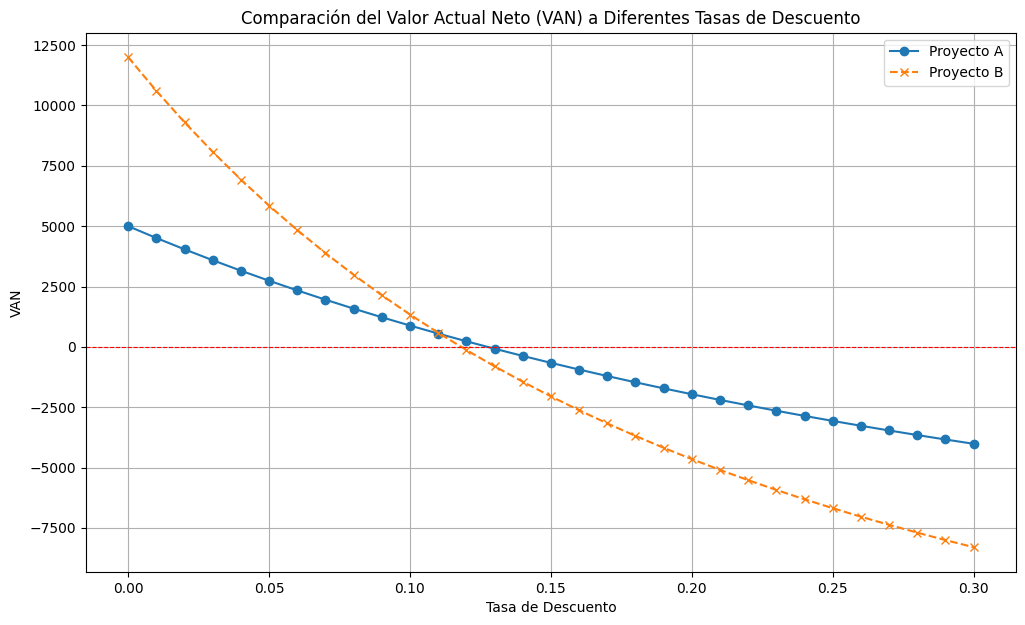

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy_financial as nf

# Definimos rango de tasas de descuento
tasas_descuento_rango = np.arange(0, 0.31, 0.01)

# Calculamos VAN para cada tasa en el  Projecto A
van_proyecto_a_rango = [nf.npv(tasa, flujos_proyecto_a) for tasa in tasas_descuento_rango]

# Calculamos VAN para cada tasa en el  Projecto B
van_proyecto_b_rango = [nf.npv(tasa, flujos_proyecto_b) for tasa in tasas_descuento_rango]

# Creamos el gráfico
plt.figure(figsize=(12, 7))
plt.plot(tasas_descuento_rango, van_proyecto_a_rango, marker='o', linestyle='-', label='Proyecto A')
plt.plot(tasas_descuento_rango, van_proyecto_b_rango, marker='x', linestyle='--', label='Proyecto B')


plt.title('Comparación del Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')


plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.legend()
plt.show()

Interpretación del Gráfico Comparativo del VAN:
- El gráfico muestra cómo el VAN de cada proyecto cambia a medida que varía la tasa de descuento.
- La TIR de cada proyecto (12.75% para el Proyecto A y 11.81% para el Proyecto B) corresponde al punto donde su respectiva curva cruza el eje horizontal (VAN = 0).

Comparación de las Curvas del VAN:
- La curva del Proyecto A cruza el eje horizontal a una tasa de descuento más alta (12.75%) que la curva del Proyecto B (11.81%). Esto visualmente confirma que el Proyecto A tiene una TIR más alta.
- Para tasas de descuento por debajo de la TIR del Proyecto B (11.81%), ambos proyectos tienen VANs positivos. En este rango, el proyecto con la curva más alta (mayor VAN) sería preferible.
- Para tasas de descuento entre la TIR del Proyecto B (11.81%) y la TIR del Proyecto A (12.75%), el Proyecto A tiene un VAN positivo mientras que el Proyecto B tiene un VAN negativo. En este rango, solo el Proyecto A sería aceptable según el criterio del VAN.
- Para tasas de descuento por encima de la TIR del Proyecto A (12.75%), ambos proyectos tienen VANs negativos. En este rango, el proyecto con el VAN menos negativo (la curva más alta) sería el menos desfavorable.

---

